In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from libpysal.weights import lat2W
from scipy.stats import norm


In [ ]:
# Configuramos la grilla
n_rows, n_cols = 20, 20
np.random.seed(42)

# Imagen de referencia (verdad): zonas homogéneas
reference = np.random.choice([0, 1], size=(n_rows, n_cols), p=[0.6, 0.4])

# Imagen clasificada con errores
classified = reference.copy()
mask = np.random.rand(n_rows, n_cols) < 0.15  # 15% de error
classified[mask] = 1 - classified[mask]  # invertir clase en error

# Imagen de diferencia (error)
errors = (classified != reference).astype(int)


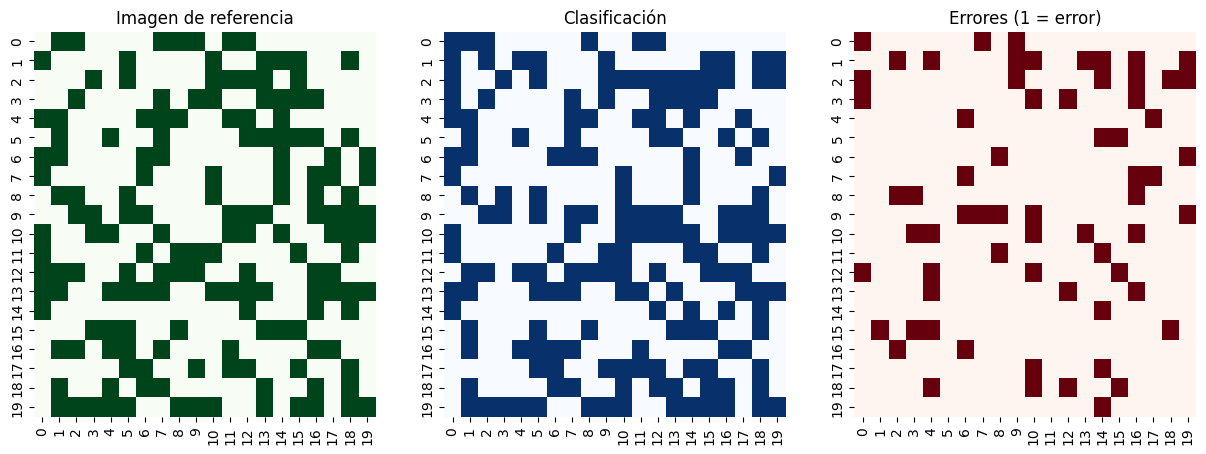

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.heatmap(reference, cmap="Greens", cbar=False, ax=axs[0])
axs[0].set_title("Imagen de referencia")

sns.heatmap(classified, cmap="Blues", cbar=False, ax=axs[1])
axs[1].set_title("Clasificación")

sns.heatmap(errors, cmap="Reds", cbar=False, ax=axs[2])
axs[2].set_title("Errores (1 = error)")

plt.show()


In [ ]:
# Crear lista de valores (0 o 1) como vector plano
x = errors.flatten()
N = x.shape[0]

# Matriz de pesos espaciales (adyacencia tipo rook)
w = lat2W(n_rows, n_cols)  # vecinos 4 direcciones
w.transform = 'b'  # binaria

# Calcular número de 1-1 joins (errores vecinos)
BB = 0
for i in range(N):
    for j in w.neighbors[i]:
        if i < j and x[i] == 1 and x[j] == 1:
            BB += 1

# Mostrar resultado
print(f"Errores vecinos (1-1 joins): {BB}")


Errores vecinos (1-1 joins): 21


In [ ]:
n1 = np.sum(x)       # total de errores
n0 = N - n1
p = n1 / N
q = 1 - p
J = sum(len(w.neighbors[i]) for i in range(N)) // 2  # total de joins

# Esperanza y varianza de 1-1 joins bajo H0 (aleatoriedad)
E_BB = J * p * p
Var_BB = J * p * p * (1 - p * p)

# Estadístico Z (normal estándar)
Z = (BB - E_BB) / np.sqrt(Var_BB)

print(f"Esperado bajo H0 (E[BB]): {E_BB:.2f}")
print(f"Varianza bajo H0 (Var[BB]): {Var_BB:.2f}")
print(f"Z-score: {Z:.2f}")
print(f"P-valor (1 cola): {1 - norm.cdf(Z):.4f}")


Esperado bajo H0 (E[BB]): 20.69
Varianza bajo H0 (Var[BB]): 20.13
Z-score: 0.07
P-valor (1 cola): 0.4725


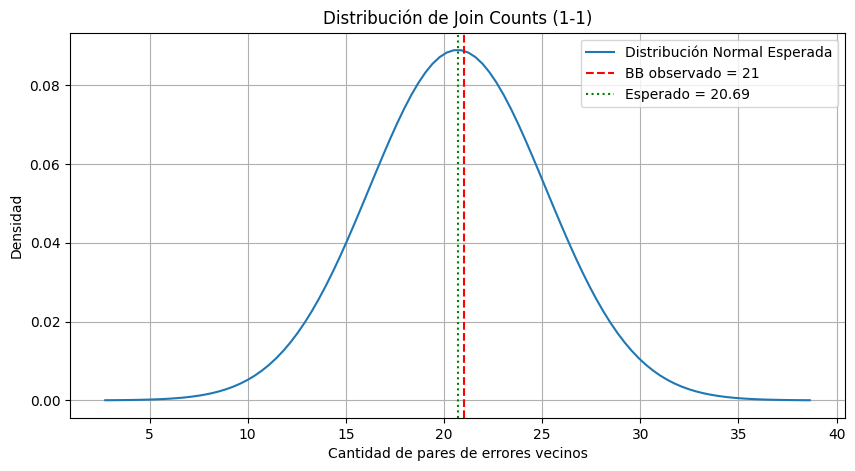

In [ ]:
x_vals = np.linspace(E_BB - 4*np.sqrt(Var_BB), E_BB + 4*np.sqrt(Var_BB), 100)
y_vals = norm.pdf(x_vals, loc=E_BB, scale=np.sqrt(Var_BB))

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='Distribución Normal Esperada')
plt.axvline(BB, color='red', linestyle='--', label=f'BB observado = {BB}')
plt.axvline(E_BB, color='green', linestyle=':', label=f'Esperado = {E_BB:.2f}')
plt.title("Distribución de Join Counts (1-1)")
plt.xlabel("Cantidad de pares de errores vecinos")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()


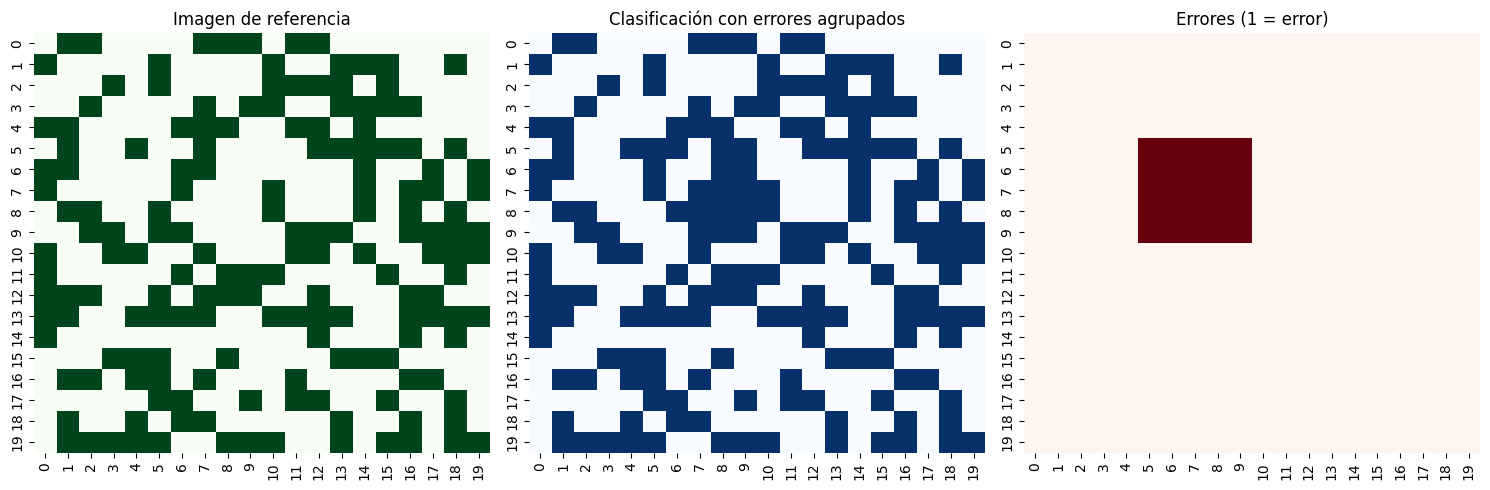

 Errores vecinos (1-1 joins): 40
 Esperado bajo H0: 5.94
 Varianza esperada: 5.91
 Z-score: 14.01
 p-valor (1 cola): 0.0


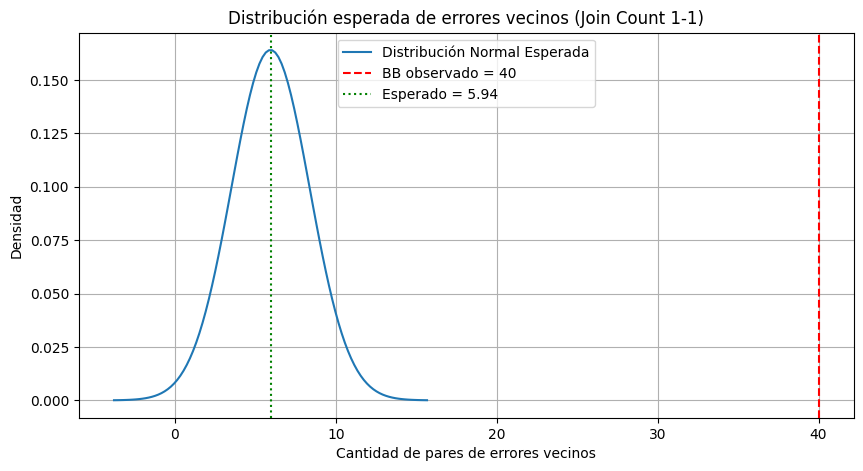

In [ ]:
#  Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

#  Simulación de datos con errores agrupados
n_rows, n_cols = 20, 20
np.random.seed(42)

# Imagen de referencia (verde)
reference = np.random.choice([0, 1], size=(n_rows, n_cols), p=[0.6, 0.4])

# Imagen clasificada (igual al inicio)
classified = reference.copy()

# Agrupar errores en un bloque 5x5
classified[5:10, 5:10] = 1 - reference[5:10, 5:10]

# Imagen de errores
errors = (classified != reference).astype(int)

#  Visualización de las tres imágenes
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.heatmap(reference, cmap="Greens", cbar=False, ax=axs[0])
axs[0].set_title("Imagen de referencia")

sns.heatmap(classified, cmap="Blues", cbar=False, ax=axs[1])
axs[1].set_title("Clasificación con errores agrupados")

sns.heatmap(errors, cmap="Reds", cbar=False, ax=axs[2])
axs[2].set_title("Errores (1 = error)")

plt.tight_layout()
plt.show()

#  Conteo conjunto 1-1 (errores vecinos)
x = errors.flatten()
N = x.shape[0]

def get_neighbors(i, j, n_rows, n_cols):
    neighbors = []
    if i > 0: neighbors.append((i - 1, j))
    if i < n_rows - 1: neighbors.append((i + 1, j))
    if j > 0: neighbors.append((i, j - 1))
    if j < n_cols - 1: neighbors.append((i, j + 1))
    return neighbors

BB = 0
for i in range(n_rows):
    for j in range(n_cols):
        if errors[i, j] == 1:
            for ni, nj in get_neighbors(i, j, n_rows, n_cols):
                if (ni > i) or (ni == i and nj > j):  # evitar duplicados
                    if errors[ni, nj] == 1:
                        BB += 1

#  Cálculo de estadístico Z
n1 = np.sum(x)
p = n1 / N
J = 2 * n_rows * (n_cols - 1) + 2 * n_cols * (n_rows - 1)
E_BB = J * p * p
Var_BB = J * p * p * (1 - p * p)
Z = (BB - E_BB) / np.sqrt(Var_BB)
p_value = 1 - norm.cdf(Z)

# 📋 Resultados
print(" Errores vecinos (1-1 joins):", BB)
print(" Esperado bajo H0:", round(E_BB, 2))
print(" Varianza esperada:", round(Var_BB, 2))
print(" Z-score:", round(Z, 2))
print(" p-valor (1 cola):", round(p_value, 4))

# 📉 Visualización de la distribución esperada vs observada
x_vals = np.linspace(E_BB - 4*np.sqrt(Var_BB), E_BB + 4*np.sqrt(Var_BB), 100)
y_vals = norm.pdf(x_vals, loc=E_BB, scale=np.sqrt(Var_BB))

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='Distribución Normal Esperada')
plt.axvline(BB, color='red', linestyle='--', label=f'BB observado = {BB}')
plt.axvline(E_BB, color='green', linestyle=':', label=f'Esperado = {E_BB:.2f}')
plt.title("Distribución esperada de errores vecinos (Join Count 1-1)")
plt.xlabel("Cantidad de pares de errores vecinos")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()
